# K-Means 알고리즘 설명
K-Means(K-평균)는 주어진 데이터를 특성이 비슷한 'K'개의 그룹(클러스터)으로 묶어주는 대표적인 비지도 학습 군집화(Clustering) 알고리즘입니다.

## 예시 파일
10.1.Outlier.ipynb

## 답변
K-Means 알고리즘은 정답(Label)이 없는 데이터들을 서로 가까운 위치에 있는 것들끼리 묶어 의미 있는 결과를 찾아내는 데 사용됩니다. (예: 고객 세분화, 이미지 압축, 이상치 탐지 등)

### 동작 원리
1. **K값 설정:** 데이터를 몇 개의 그룹(K)으로 나눌지 미리 정합니다.
2. **중심점(Centroid) 무작위 배치:** K개의 중심점을 데이터 공간에 임의로 찍습니다.
3. **군집 할당:** 모든 데이터 포인트들을 가장 가까운 중심점이 있는 그룹으로 배정합니다. 주로 유클리드 거리($\sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$)를 사용합니다.
4. **중심점 이동:** 그룹별로 할당된 데이터들의 평균 위치(무게 중심)를 계산하여, 중심점을 그 위치로 이동시킵니다.
5. **반복:** 더 이상 중심점이 이동하지 않거나 정해진 횟수에 도달할 때까지 3~4번 과정을 반복합니다.

### 특징 및 유의할 점
- **장점:** 알고리즘이 쉽고 간결하며, 대용량 데이터에서도 계산 속도가 매우 빠릅니다.
- **단점:** K값을 사용자가 직접 정해줘야 하며, 이상치(Outlier)에 중심점이 끌려가기 때문에 이상치에 민감합니다. 앞서 다룬 이상치 처리(Z-score, IQR) 후 적용하는 것이 좋습니다.


### 추가 자료
- [Scikit-Learn 공식 문서 (KMeans)](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [위키백과 (K-평균 알고리즘)](https://ko.wikipedia.org/wiki/K-%ED%8F%89%EA%B7%A0_%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98)

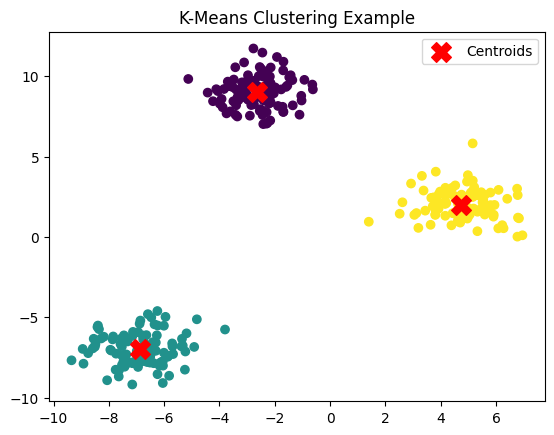

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. 예시 데이터 생성 (3개의 군집을 가진 가상 데이터)
X, y = make_blobs(n_samples=300, centers=3, random_state=42)

# 2. K-Means 모델 생성 및 학습 (K=3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# 3. 데이터가 할당된 그룹(클러스터)과 중심점 확인
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 4. 시각화
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering Example")
plt.legend()
plt.show()